In [69]:
import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf

from tensorflow.keras.layers import Input, Lambda, Dense, Reshape, Flatten, \
    LSTM, Concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

from math import *

from sklearn.metrics import mean_squared_error

tf.compat.v1.enable_eager_execution()

In [70]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [71]:
obs_data = np.load('/content/gdrive/My Drive/Colab Notebooks/Visobs.npy', allow_pickle=True)
combined_data = obs_data

In [72]:
data_list = []

for element in combined_data: 
  if element != 9999.0:
    data_list.append(element)

print(len(data_list))

4133


In [73]:
combined_data = np.array(data_list)
print(combined_data)
print(len(combined_data))
arr_length = len(combined_data)

[8666.66666667 4066.66666667 9333.         ... 7000.         7999.66666667
 5399.66666667]
4133


In [74]:
temp_data = combined_data

combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
print(combined_data)
print(len(combined_data))

[8666.66666667 4066.66666667 9333.         ... 7000.         7999.66666667
 5399.66666667]
20665


In [75]:
combined_data = np.reshape(combined_data, (arr_length,5), order = 'F')
print(combined_data)
print(combined_data.shape)

[[8666.66666667 8666.66666667 8666.66666667 8666.66666667 8666.66666667]
 [4066.66666667 4066.66666667 4066.66666667 4066.66666667 4066.66666667]
 [9333.         9333.         9333.         9333.         9333.        ]
 ...
 [7000.         7000.         7000.         7000.         7000.        ]
 [7999.66666667 7999.66666667 7999.66666667 7999.66666667 7999.66666667]
 [5399.66666667 5399.66666667 5399.66666667 5399.66666667 5399.66666667]]
(4133, 5)


3719


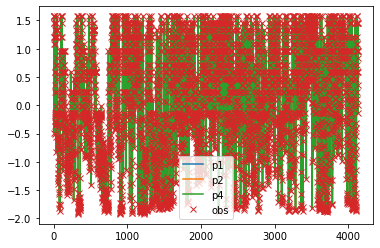

In [76]:
# Split into training data
TRAIN_SPLIT = np.int(0.9*len(combined_data))
print(TRAIN_SPLIT)

# Normalize the training data
data_mean = np.mean(combined_data[:TRAIN_SPLIT], axis=0)
data_std = np.std(combined_data[:TRAIN_SPLIT], axis=0)

dataset = (combined_data-data_mean)/data_std

# Plot part of data to make sure concatenation and normalization was successful
plt.plot(dataset[:,0])
plt.plot(dataset[:,1])
plt.plot(dataset[:,3])
plt.plot(dataset[:,4],'x')
plt.legend(['p1','p2','p4','obs'])

In [77]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

past_history = 48
future_target = 6
STEP = 1

x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [78]:
# Data shape
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('\n Target temperature to predict : {}'.format(y_train_multi[0].shape))

BATCH_SIZE = 16
BUFFER_SIZE = 1000000

train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

Single window of past history : (48, 5)

 Target temperature to predict : (6,)


In [79]:
def create_time_steps(length):
  return list(range(-length, 0))

mean_error_ave = 0

In [80]:
def multi_step_plot(history, true_future, prediction):
  global mean_error_ave
  x = np.array(true_future).tolist()
  y = np.array(prediction).tolist()
  mean = 0
  for i in range(6) :
    mean = mean + ((x[i] - y[i])**2)
  mean_error = sqrt(mean/6)
  print("mean error is ", mean_error)
  mean_error_ave = mean_error_ave + (mean_error/6)
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'b',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'r',
             label='Predicted Future')
  plt.legend(loc='upper left')
  plt.show()

In [81]:
#for x, y in train_data_multi.take(1):
  #multi_step_plot(x[0], y[0], np.array([0]))

multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.LSTM(32,
                                          return_sequences=True,
                                          input_shape=x_train_multi.shape[-2:]))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='softsign'))
multi_step_model.add(tf.keras.layers.Dense(future_target))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss='mae')

EVALUATION_INTERVAL = 200
EPOCHS = 10

multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/10
200/200 [==============================] - 7s 33ms/step - loss: 0.7278 - val_loss: 0.7387
Epoch 2/10
200/200 [==============================] - 6s 30ms/step - loss: 0.6427 - val_loss: 0.6866
Epoch 3/10
200/200 [==============================] - 6s 31ms/step - loss: 0.6087 - val_loss: 0.6734
Epoch 4/10
200/200 [==============================] - 6s 30ms/step - loss: 0.6035 - val_loss: 0.6720
Epoch 5/10
200/200 [==============================] - 6s 30ms/step - loss: 0.5994 - val_loss: 0.6699
Epoch 6/10
200/200 [==============================] - 6s 31ms/step - loss: 0.5944 - val_loss: 0.6768
Epoch 7/10
200/200 [==============================] - 6s 31ms/step - loss: 0.5991 - val_loss: 0.6731
Epoch 8/10
200/200 [==============================] - 6s 32ms/step - loss: 0.5948 - val_loss: 0.6691
Epoch 9/10
200/200 [==============================] - 6s 32ms/step - loss: 0.5911 - val_loss: 0.6711
Epoch 10/10
200/200 [==============================] - 6s 31ms/step - loss: 0.6002 - val_lo

In [82]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

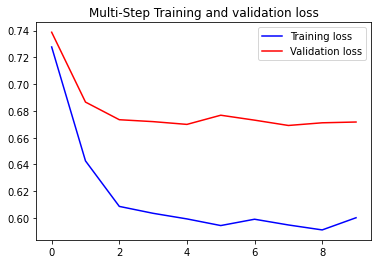

mean error is  1912.9348255289392


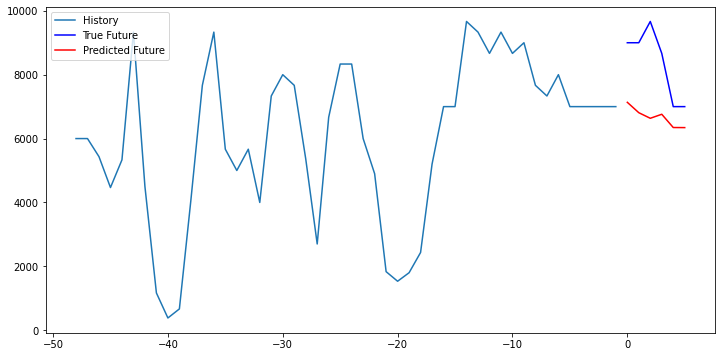

mean error is  1533.4054376003323


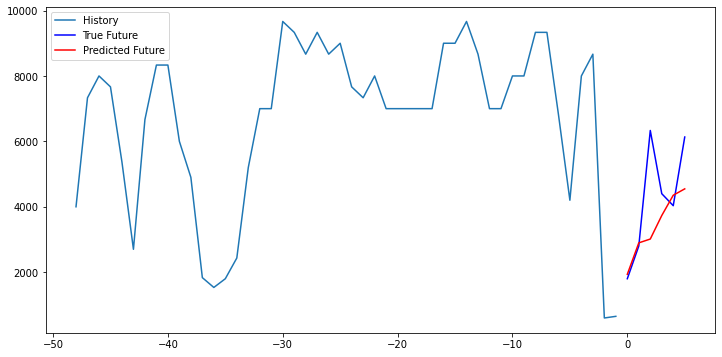

mean error is  2228.024944223496


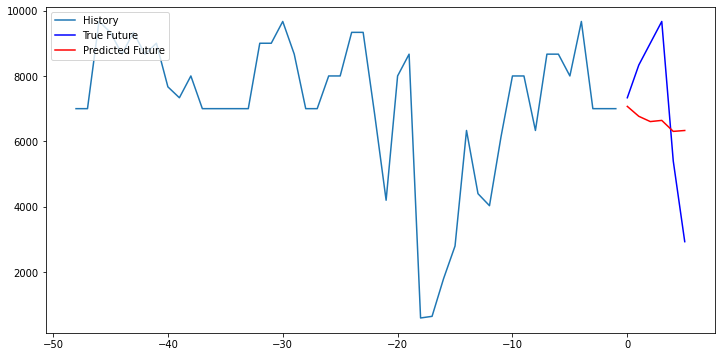

mean error is  2159.7229684400218


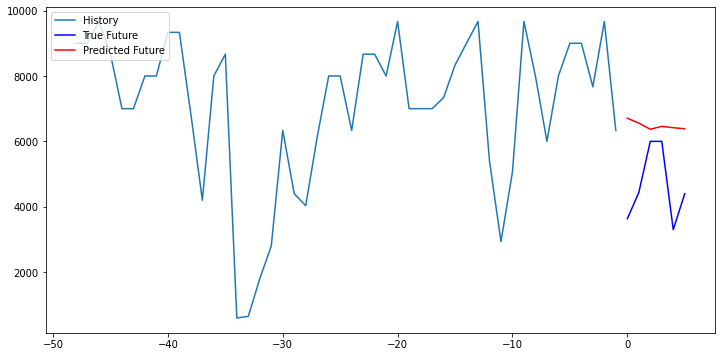

mean error is  761.4883974308519


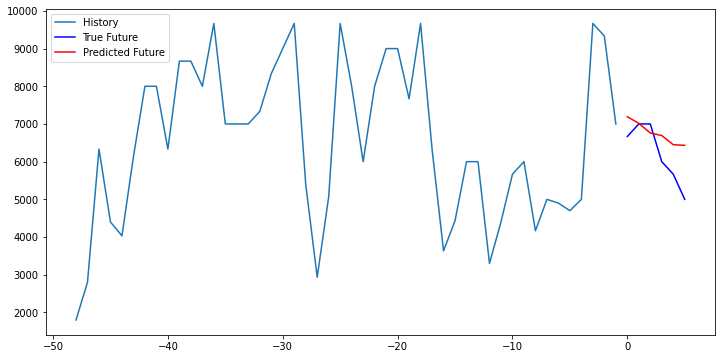

mean error is  2109.1176492557006


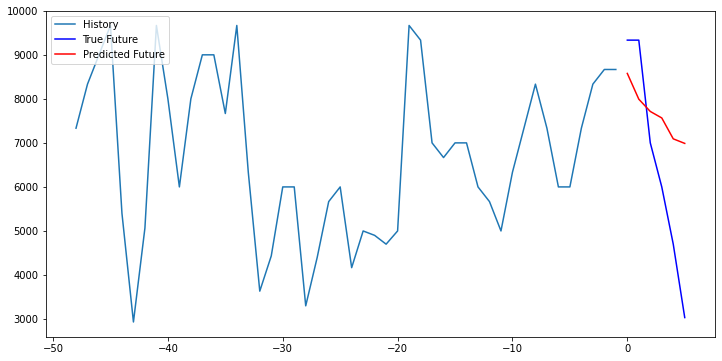

mean error average is  1784.115703746557


In [83]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

for x, y in val_data_multi.take(6):
  multi_step_plot(data_mean[4]+data_std[4]*x[0], data_mean[4]+data_std[4]*y[0], 
                  data_mean[4]+data_std[4]*multi_step_model.predict(x)[0])

print("mean error average is ", mean_error_ave)